In [2]:
2+2

4

In [3]:
import glob
import json
import pandas as pd

records = []

files = glob.glob(
    r"C:\Users\Aman Kumar Singh\Desktop\nlp_dissertation\testing_coverage\coverage_testing_2_*.jsonl"
)

for filename in sorted(files):

    with open(filename, "r", encoding="utf-8") as f:

        for line in f:

            if not line.strip():
                continue

            data = json.loads(line)

            # Factuality scores
            factuality = data.get("factuality_scores", {})

            patient_score = factuality.get(
                "patient_factuality_score"
            )

            syndrome_score = factuality.get(
                "syndrome_factuality_score"
            )

            # Calculate average factuality
            if patient_score is not None and syndrome_score is not None:
                factuality_average = (
                    patient_score + syndrome_score
                ) / 2
            else:
                factuality_average = None

            # Coverage score
            coverage = data.get("coverage_scores", {})

            coverage_score = coverage.get(
                "patient_coverage_score"
            )

            records.append({
                "index": data.get("index"),
                "consultation": data.get("consultation"),
                "report": data.get("report"),
                "factuality_score": factuality_average,
                "coverage_score": coverage_score
            })


# Create DataFrame
df = pd.DataFrame(records)

print(df.shape)

# Add serial number
df.insert(
    0,
    "serial_number",
    range(1, len(df) + 1)
)

# Round scores
df["factuality_score"] = df["factuality_score"].round(4)
df["coverage_score"] = df["coverage_score"].round(4)

print(df.head())
print(df.shape)

(492, 5)
   serial_number  index                                       consultation  \
0              1      0  Doctor: Please tell us about any problems with...   
1              2      1  Doctor: Please tell us about any problems with...   
2              3      2  Doctor: Please tell us about any problems with...   
3              4      3  Doctor: Please tell us about any problems with...   
4              5      4  Doctor: Please tell us about any problems with...   

                                              report  factuality_score  \
0  # CLINICAL PATIENT REPORT\n\n## 1) RESPIRATORY...            0.8750   
1  # CLINICAL PATIENT REPORT\n\n## 1) RESPIRATORY...            0.8576   
2  # CLINICAL PATIENT REPORT\n\n## 1) RESPIRATORY...            0.8334   
3  # CLINICAL PATIENT REPORT\n\n## 1) RESPIRATORY...            0.9402   
4  # CLINICAL PATIENT REPORT\n\n## 1) RESPIRATORY...            0.9565   

   coverage_score  
0          0.6250  
1          0.8462  
2          0.8750

In [4]:
import re
import pandas as pd

def clean_report(text):
    if pd.isna(text):
        return text

    # Remove markdown headers
    text = re.sub(
        r'^#+\s*',
        '',
        text,
        flags=re.MULTILINE
    )

    # Remove bullet points
    text = re.sub(
        r'^\s*[-*]\s+',
        '',
        text,
        flags=re.MULTILINE
    )

    # Replace newlines with spaces
    text = re.sub(
        r'\s*\n\s*',
        ' ',
        text
    )

    # Remove multiple spaces
    text = re.sub(
        r'\s+',
        ' ',
        text
    )

    return text.strip()


# Create cleaned report column
df["cleaned_report"] = df["report"].apply(clean_report)

In [5]:
df.head()

,serial_number,index,consultation,report,factuality_score,coverage_score,cleaned_report
0,1,0,Doctor: Please tell us about any problems with...,# CLINICAL PATIENT REPORT\n\n## 1) RESPIRATORY...,0.8750,0.6250,CLINICAL PATIENT REPORT 1) RESPIRATORY a) How ...
1,2,1,Doctor: Please tell us about any problems with...,# CLINICAL PATIENT REPORT\n\n## 1) RESPIRATORY...,0.8576,0.8462,CLINICAL PATIENT REPORT 1) RESPIRATORY a) How ...
2,3,2,Doctor: Please tell us about any problems with...,# CLINICAL PATIENT REPORT\n\n## 1) RESPIRATORY...,0.8334,0.8750,CLINICAL PATIENT REPORT 1) RESPIRATORY a) How ...
3,4,3,Doctor: Please tell us about any problems with...,# CLINICAL PATIENT REPORT\n\n## 1) RESPIRATORY...,0.9402,0.4545,CLINICAL PATIENT REPORT 1) RESPIRATORY a) How ...
4,5,4,Doctor: Please tell us about any problems with...,# CLINICAL PATIENT REPORT\n\n## 1) RESPIRATORY...,0.9565,1.0000,CLINICAL PATIENT REPORT 1) RESPIRATORY a) How ...


In [6]:
from transformers import AutoTokenizer
import pandas as pd

MODEL_ID = "Qwen/Qwen3-30B-A3B-Instruct-2507"

print("Loading tokenizer...", flush=True)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID
)

print("Tokenizer loaded successfully\n", flush=True)


def get_token_length(text):
    if pd.isna(text):
        return 0

    tokens = tokenizer.encode(
        str(text),
        add_special_tokens=True
    )

    return len(tokens)


print("Calculating token lengths...", flush=True)

df["cleaned_token_length"] = df["cleaned_report"].apply(
    get_token_length
)

print("Token length calculation completed successfully.\n")

print(
    df[
        [
            "serial_number",
            "index",
            "cleaned_token_length"
        ]
    ].head()
)

print("\nShape:", df.shape)

Loading tokenizer...


Tokenizer loaded successfully

Calculating token lengths...
Token length calculation completed successfully.

   serial_number  index  cleaned_token_length
0              1      0                   814
1              2      1                   845
2              3      2                   826
3              4      3                   877
4              5      4                   959

Shape: (492, 8)


In [7]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Min-max normalize cleaned report token length
L_norm = MinMaxScaler().fit_transform(
    df[["cleaned_token_length"]]
).flatten()

# Brevity factor
brevity_factor = 1 - L_norm

# Geometric mean conciseness score
conciseness_geo = (
    df["coverage_score"]
    * df["factuality_score"]
    * brevity_factor
) ** (1/3)

# Add the score to the DataFrame
df["conciseness_score"] = conciseness_geo



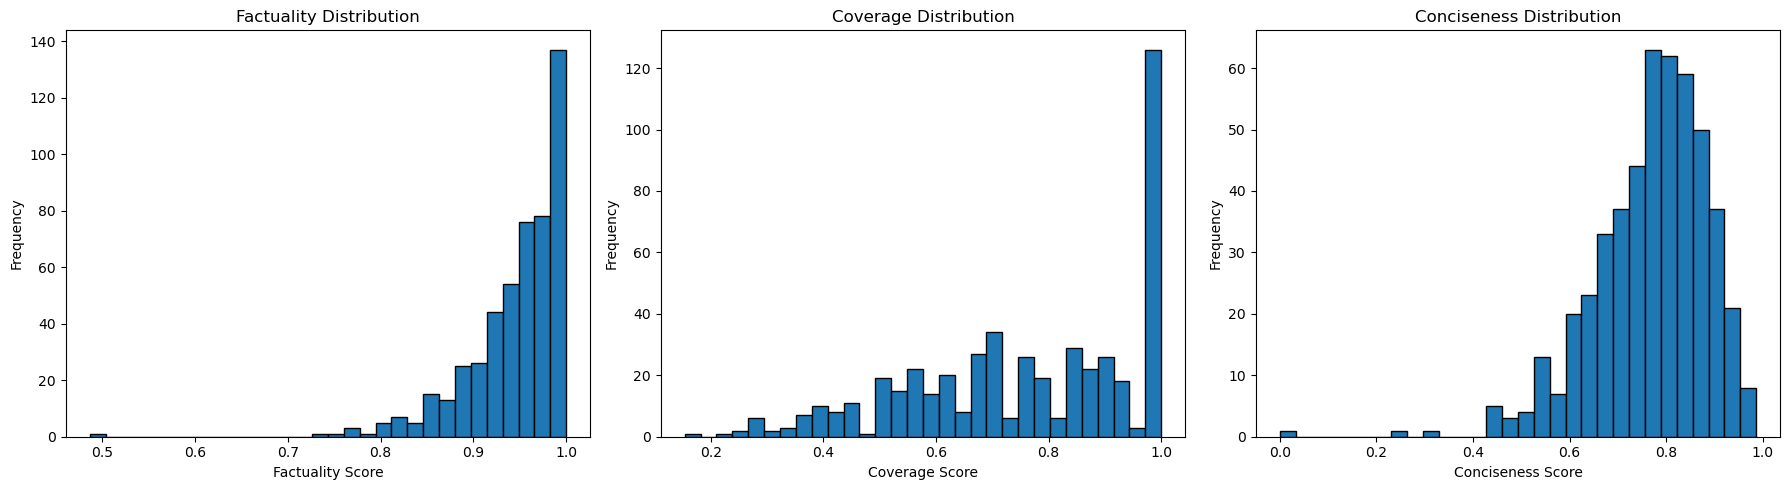

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Factuality
axes[0].hist(
    df["factuality_score"],
    bins=30,
    edgecolor="black"
)
axes[0].set_xlabel("Factuality Score")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Factuality Distribution")

# Coverage
axes[1].hist(
    df["coverage_score"],
    bins=30,
    edgecolor="black"
)
axes[1].set_xlabel("Coverage Score")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Coverage Distribution")

# Conciseness
axes[2].hist(
    df["conciseness_score"],
    bins=30,
    edgecolor="black"
)
axes[2].set_xlabel("Conciseness Score")
axes[2].set_ylabel("Frequency")
axes[2].set_title("Conciseness Distribution")

plt.tight_layout()
plt.show()

In [9]:
# Sort by factuality score (highest to lowest)
df = df.sort_values(
    by="factuality_score",
    ascending=False
).reset_index(drop=True)

# Save the sorted dataset
output_path = r"C:\Users\Aman Kumar Singh\Desktop\nlp_dissertation\Distillation\Testing\test_scores_dataset.csv"

df.to_csv(
    output_path,
    index=False,
    encoding="utf-8"
)

print(f"Dataset saved successfully to:\n{output_path}")

Dataset saved successfully to:
C:\Users\Aman Kumar Singh\Desktop\nlp_dissertation\Distillation\Testing\test_scores_dataset.csv


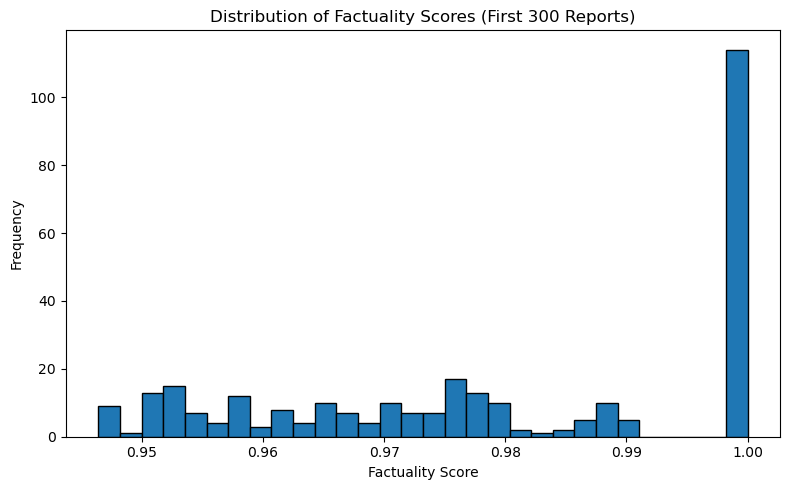

In [10]:
import matplotlib.pyplot as plt

# First 300 factuality scores
factuality_300 = df["factuality_score"].iloc[:300]

plt.figure(figsize=(8, 5))

plt.hist(
    factuality_300,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Factuality Score")
plt.ylabel("Frequency")
plt.title("Distribution of Factuality Scores (First 300 Reports)")

plt.tight_layout()
plt.show()

In [11]:
import json
import os

output_dir = r"C:\Users\Aman Kumar Singh\Desktop\nlp_dissertation\Distillation\Testing"

os.makedirs(output_dir, exist_ok=True)

# Take first 300 rows
top_300 = df.iloc[:300].reset_index(drop=True)

# Create 6 files, 50 records each
for i in range(6):

    chunk = top_300.iloc[i * 50:(i + 1) * 50]

    output_file = os.path.join(
        output_dir,
        f"testing_consultations_{i+1:02d}.jsonl"
    )

    with open(output_file, "w", encoding="utf-8") as f:

        for j, (_, row) in enumerate(chunk.iterrows()):

            record = {
                "patient_id": i * 50 + j + 1,
                "consultation": row["consultation"]
            }

            f.write(
                json.dumps(
                    record,
                    ensure_ascii=False
                ) + "\n"
            )

    print(
        f"{os.path.basename(output_file)}: "
        f"{len(chunk)} records"
    )

testing_consultations_01.jsonl: 50 records
testing_consultations_02.jsonl: 50 records
testing_consultations_03.jsonl: 50 records
testing_consultations_04.jsonl: 50 records
testing_consultations_05.jsonl: 50 records
testing_consultations_06.jsonl: 50 records


In [12]:
df_300 = df.iloc[:300].copy()

# Reset the DataFrame index
df_300 = df_300.reset_index(drop=True)

# Save the first 300 records
output_path = r"C:\Users\Aman Kumar Singh\Desktop\nlp_dissertation\Distillation\Testing\test_scores_dataset_300.csv"

df_300.to_csv(
    output_path,
    index=False,
    encoding="utf-8"
)

print(f"First 300 dataset saved successfully to:\n{output_path}")
print("Shape:", df_300.shape)

First 300 dataset saved successfully to:
C:\Users\Aman Kumar Singh\Desktop\nlp_dissertation\Distillation\Testing\test_scores_dataset_300.csv
Shape: (300, 9)


In [13]:
df_300 = df.iloc[:300].copy()

# Reset the DataFrame index
df_300 = df_300.reset_index(drop=True)

# Save the first 300 records
output_path = r"C:\Users\Aman Kumar Singh\Desktop\nlp_dissertation\Distillation\Testing\Teachermodel\test_scores_dataset_300.csv"

df_300.to_csv(
    output_path,
    index=False,
    encoding="utf-8"
)

print(f"First 300 dataset saved successfully to:\n{output_path}")
print("Shape:", df_300.shape)

First 300 dataset saved successfully to:
C:\Users\Aman Kumar Singh\Desktop\nlp_dissertation\Distillation\Testing\Teachermodel\test_scores_dataset_300.csv
Shape: (300, 9)


In [14]:
import pandas as pd

# Load the dataset
input_path = r"C:\Users\Aman Kumar Singh\Desktop\nlp_dissertation\Distillation\Testing\Teachermodel\test_scores_dataset.csv"

df = pd.read_csv(input_path)

print("Dataset loaded successfully.")
print("Original shape:", df.shape)

# Create dataset containing only the first 300 rows
df_300 = df.iloc[:300].copy()

# Reset index
df_300 = df_300.reset_index(drop=True)

print("First 300 dataset shape:", df_300.shape)
print(df_300.head())

Dataset loaded successfully.
Original shape: (492, 9)
First 300 dataset shape: (300, 9)
   serial_number  index                                       consultation  \
0             15     14  Doctor: Please tell us about any problems with...   
1            470     25  Doctor: Please tell us about any problems with...   
2            275     26  Doctor: Please tell us about any problems with...   
3            245     46  Doctor: Please tell us about any problems with...   
4            258      9  Doctor: Please tell us about any problems with...   

                                              report  factuality_score  \
0  # CLINICAL PATIENT REPORT\n\n## 1) RESPIRATORY...               1.0   
1  # CLINICAL PATIENT REPORT\n\n## 1) RESPIRATORY...               1.0   
2  # CLINICAL PATIENT REPORT\n\n## 1) RESPIRATORY...               1.0   
3  # CLINICAL PATIENT REPORT\n\n## 1) RESPIRATORY...               1.0   
4  # CLINICAL PATIENT REPORT\n\n## 1) RESPIRATORY...               1.0   

In [ ]:
output_path = r"C:\Users\Aman Kumar Singh\Desktop\nlp_dissertation\Distillation\Testing\Teachermodel\test_scores_dataset_300.csv"

df_300.to_csv(
    output_path,
    index=False,
    encoding="utf-8"
)

print(f"\nFirst 300 dataset saved successfully to:\n{output_path}")


First 300 dataset saved successfully to:
C:\Users\Aman Kumar Singh\Desktop\nlp_dissertation\Distillation\Testing\Teachermodel\test_scores_dataset_300.csv


In [ ]:
df1 = pd.read_csv(r"C:\Users\Aman Kumar Singh\Desktop\nlp_dissertation\Distillation\Testing\Teachermodel\test_scores_dataset_300.csv")


In [ ]:
df.tail(5)

,serial_number,index,consultation,report,factuality_score,coverage_score,cleaned_report,cleaned_token_length,conciseness_score
0,15,14,Doctor: Please tell us about any problems with...,# CLINICAL PATIENT REPORT\n\n## 1) RESPIRATORY...,1.0,0.5714,CLINICAL PATIENT REPORT 1) RESPIRATORY a) How ...,826,0.767247
1,470,25,Doctor: Please tell us about any problems with...,# CLINICAL PATIENT REPORT\n\n## 1) RESPIRATORY...,1.0,0.5385,CLINICAL PATIENT REPORT 1) RESPIRATORY a) How ...,1046,0.538074
2,275,26,Doctor: Please tell us about any problems with...,# CLINICAL PATIENT REPORT\n\n## 1) RESPIRATORY...,1.0,0.6250,CLINICAL PATIENT REPORT 1) RESPIRATORY a) How ...,887,0.741186
3,245,46,Doctor: Please tell us about any problems with...,# CLINICAL PATIENT REPORT\n\n## 1) RESPIRATORY...,1.0,0.9091,CLINICAL PATIENT REPORT 1) RESPIRATORY a) How ...,888,0.838811
4,258,9,Doctor: Please tell us about any problems with...,# CLINICAL PATIENT REPORT\n\n## 1) RESPIRATORY...,1.0,0.8750,CLINICAL PATIENT REPORT 1) RESPIRATORY a) How ...,832,0.879224


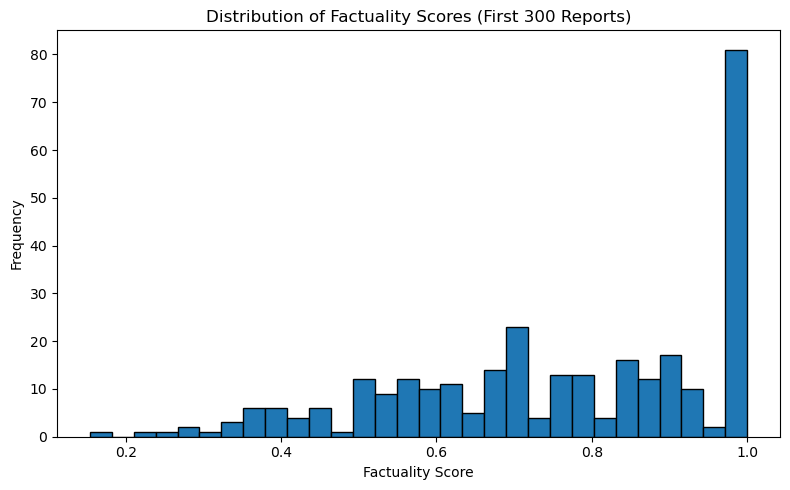

In [17]:
import matplotlib.pyplot as plt

# First 300 factuality scores
factuality_300 = df["coverage_score"].iloc[:300]

plt.figure(figsize=(8, 5))

plt.hist(
    factuality_300,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Factuality Score")
plt.ylabel("Frequency")
plt.title("Distribution of Factuality Scores (First 300 Reports)")

plt.tight_layout()
plt.show()

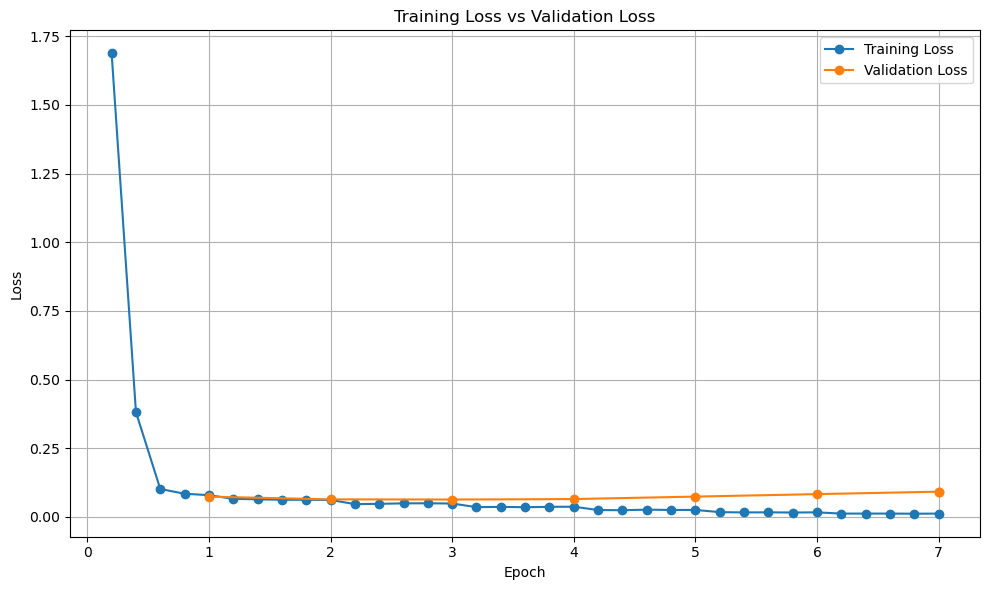

In [19]:
import json
import matplotlib.pyplot as plt

# Load JSON
with open(r"C:\Users\Aman Kumar Singh\Desktop\nlp_dissertation\Distillation\previous_sft_loss_history.json", "r") as f:
    data = json.load(f)

# Get losses
training_loss = data["training_loss"]
validation_loss = data["validation_loss"]

# -----------------------------
# Extract epoch and loss values
# -----------------------------

train_epochs = [x["epoch"] for x in training_loss]
train_values = [x["loss"] for x in training_loss]

val_epochs = [x["epoch"] for x in validation_loss]
val_values = [x["loss"] for x in validation_loss]

# -----------------------------
# Plot
# -----------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    train_epochs,
    train_values,
    marker="o",
    label="Training Loss"
)

plt.plot(
    val_epochs,
    val_values,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "training_vs_validation_loss.png",
    dpi=300
)

plt.show()

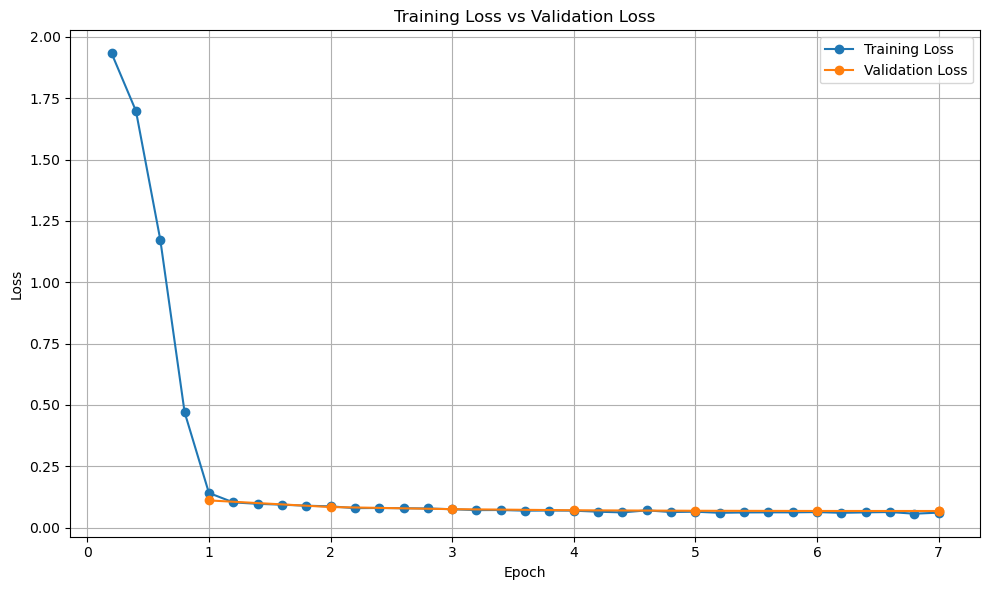

In [20]:
import json
import matplotlib.pyplot as plt

# Load JSON
with open(r"C:\Users\Aman Kumar Singh\Desktop\nlp_dissertation\Distillation\previous_sft_loss_history.json", "r") as f:
    data = json.load(f)

# Get losses
training_loss = data["training_loss"]
validation_loss = data["validation_loss"]

# -----------------------------
# Extract epoch and loss values
# -----------------------------

train_epochs = [x["epoch"] for x in training_loss]
train_values = [x["loss"] for x in training_loss]

val_epochs = [x["epoch"] for x in validation_loss]
val_values = [x["loss"] for x in validation_loss]

# -----------------------------
# Plot
# -----------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    train_epochs,
    train_values,
    marker="o",
    label="Training Loss"
)

plt.plot(
    val_epochs,
    val_values,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "training_vs_validation_loss.png",
    dpi=300
)

plt.show()

In [ ]:
## normal sft

import torch
import gc
import os
import shutil
import json

from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template
from datasets import load_dataset
from trl import SFTTrainer, SFTConfig
from transformers import TrainerCallback


# ============================================================
# CONFIGURATION
# ============================================================

MODEL_NAME = "unsloth/Qwen2.5-1.5B-Instruct"
MAX_SEQ_LENGTH = 4096

# Previous hyperparameters
LEARNING_RATE = 0.00002
LORA_RANK = 8
LORA_ALPHA = 16
EPOCHS = 5

OUTPUT_DIR = "model_sft_1"


# ============================================================
# LOAD DATASET
# ============================================================

dataset = load_dataset(
    "json",
    data_files={
        "train": "kbg_sft_train.json",
        "validation": "kbg_sft_val.json"
    }
)

print(dataset)


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":

    model = None
    trainer = None
    tokenizer = None

    try:

        # ----------------------------------------------------
        # LOAD MODEL
        # ----------------------------------------------------

        use_bf16 = torch.cuda.is_bf16_supported()

        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name=MODEL_NAME,
            max_seq_length=MAX_SEQ_LENGTH,
            dtype=torch.bfloat16 if use_bf16 else torch.float16,
            load_in_4bit=False
        )

        print("\nModel loaded successfully.")


        # ----------------------------------------------------
        # CHAT TEMPLATE
        # ----------------------------------------------------

        tokenizer = get_chat_template(
            tokenizer,
            chat_template="qwen-2.5"
        )


        # ----------------------------------------------------
        # FORMAT DATASET
        # ----------------------------------------------------

        def formatting_func(examples):

            conversations = examples["messages"]
            texts = []

            for conversation in conversations:

                text = tokenizer.apply_chat_template(
                    conversation,
                    tokenize=False,
                    add_generation_prompt=False
                )

                texts.append(text)

            return {"text": texts}


        train_dataset = dataset["train"].map(
            formatting_func,
            batched=True,
            load_from_cache_file=False
        )

        val_dataset = dataset["validation"].map(
            formatting_func,
            batched=True,
            load_from_cache_file=False
        )

        print("\nDatasets formatted successfully.")
        print("Training examples:", len(train_dataset))
        print("Validation examples:", len(val_dataset))


        # ----------------------------------------------------
        # APPLY LoRA
        # ----------------------------------------------------

        model = FastLanguageModel.get_peft_model(
            model,

            r=LORA_RANK,

            target_modules=[
                "q_proj",
                "k_proj",
                "v_proj",
                "o_proj",
                "gate_proj",
                "up_proj",
                "down_proj"
            ],

            lora_alpha=LORA_ALPHA,
            lora_dropout=0,
            bias="none",

            use_gradient_checkpointing="unsloth",

            random_state=42
        )


        print("\nLoRA configuration:")
        print("LoRA rank:", LORA_RANK)
        print("LoRA alpha:", LORA_ALPHA)


        # ----------------------------------------------------
        # LOSS TRACKING CALLBACK
        # ----------------------------------------------------

        class LossHistoryCallback(TrainerCallback):

            def __init__(self):
                self.training_losses = []
                self.validation_losses = []

            def on_log(
                self,
                args,
                state,
                control,
                logs=None,
                **kwargs
            ):

                if logs is None:
                    return

                # Training loss
                if "loss" in logs:

                    self.training_losses.append({
                        "step": int(state.global_step),
                        "epoch": float(state.epoch),
                        "loss": float(logs["loss"])
                    })

                # Validation loss
                if "eval_loss" in logs:

                    self.validation_losses.append({
                        "step": int(state.global_step),
                        "epoch": float(state.epoch),
                        "loss": float(logs["eval_loss"])
                    })


        loss_callback = LossHistoryCallback()


        # ----------------------------------------------------
        # TRAINER
        # ----------------------------------------------------

        trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LENGTH,

    args=SFTConfig(

        output_dir=OUTPUT_DIR,

        # -------------------------
        # Training
        # -------------------------

        num_train_epochs=EPOCHS,

        per_device_train_batch_size=2,

        gradient_accumulation_steps=4,

        learning_rate=LEARNING_RATE,

        warmup_ratio=0.05,

        lr_scheduler_type="cosine",

        # -------------------------
        # Precision
        # -------------------------

        bf16=use_bf16,
        fp16=not use_bf16,

        # -------------------------
        # Optimizer
        # -------------------------

        optim="adamw_8bit",

        # -------------------------
        # Evaluation
        # -------------------------

        eval_strategy="epoch",

        # -------------------------
        # Saving
        # -------------------------

        save_strategy="epoch",        # Change from "no" to "epoch"
        save_total_limit=None,

        # -------------------------
        # Logging
        # -------------------------

        logging_strategy="steps",
        logging_steps=10,

        # TensorBoard
        report_to="tensorboard",
        logging_dir=f"normal_sft/tensorboard",

    )
)

        trainer.add_callback(loss_callback)


        # ----------------------------------------------------
        # PRINT CONFIGURATION
        # ----------------------------------------------------

        print("\n")
        print("=" * 60)
        print("PREVIOUS SFT CONFIGURATION")
        print("=" * 60)

        print(f"Learning rate : {LEARNING_RATE}")
        print(f"LoRA rank     : {LORA_RANK}")
        print(f"LoRA alpha    : {LORA_ALPHA}")
        print(f"Epochs        : {EPOCHS}")
        print(f"Batch size    : 2")
        print(f"Gradient accum: 4")

        print("=" * 60)
        print("\nStarting training...\n")


        # ----------------------------------------------------
        # TRAIN
        # ----------------------------------------------------

        trainer.train()


        # ----------------------------------------------------
        # FINAL EVALUATION
        # ----------------------------------------------------

        evaluation = trainer.evaluate()

        final_val_loss = evaluation["eval_loss"]


        # ----------------------------------------------------
        # PRINT RESULTS
        # ----------------------------------------------------

        print("\n")
        print("=" * 60)
        print("TRAINING COMPLETE")
        print("=" * 60)

        print(f"Final validation loss: {final_val_loss:.4f}")

        print("\nTraining losses:")
        for item in loss_callback.training_losses:
            print(
                f"Epoch {item['epoch']:.2f} | "
                f"Step {item['step']} | "
                f"Loss {item['loss']:.4f}"
            )

        print("\nValidation losses:")
        for item in loss_callback.validation_losses:
            print(
                f"Epoch {item['epoch']:.2f} | "
                f"Step {item['step']} | "
                f"Loss {item['loss']:.4f}"
            )


        # ----------------------------------------------------
        # SAVE LOSS HISTORY
        # ----------------------------------------------------

        results = {
            "hyperparameters": {
                "learning_rate": LEARNING_RATE,
                "lora_rank": LORA_RANK,
                "lora_alpha": LORA_ALPHA,
                "epochs": EPOCHS,
                "batch_size": 2,
                "gradient_accumulation_steps": 4
            },

            "training_loss": loss_callback.training_losses,

            "validation_loss": loss_callback.validation_losses,

            "final_validation_loss": final_val_loss
        }


        with open(
            "previous_sft_loss_history.json",
            "w"
        ) as f:

            json.dump(
                results,
                f,
                indent=4
            )


        print("\n")
        print("=" * 60)
        print("LOSS HISTORY SAVED")
        print("=" * 60)

        print(
            "File: previous_sft_loss_history.json"
        )


    finally:

        # ----------------------------------------------------
        # CLEAN GPU MEMORY
        # ----------------------------------------------------

        if model is not None:
            del model

        if trainer is not None:
            del trainer

        if tokenizer is not None:
            del tokenizer

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        print("\nGPU memory cleaned.")

In [ ]:
# weighted sft
import torch
import gc
import os
import json

from datasets import load_dataset
from transformers import (
    Trainer,
    TrainingArguments,
    DataCollatorForSeq2Seq,
    TrainerCallback
)
from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template


# ============================================================
# CONFIGURATION
# ============================================================

MODEL_NAME = "unsloth/Qwen2.5-1.5B-Instruct"

MAX_SEQ_LENGTH = 4096

# Same hyperparameters as normal SFT
LEARNING_RATE = 0.00002
LORA_RANK = 8
LORA_ALPHA = 16
EPOCHS = 5

OUTPUT_DIR = "weighted_sft_qwen25_1.5b"


# ============================================================
# LOAD DATASET
# ============================================================

dataset = load_dataset(
    "json",
    data_files={
        "train": "kbg_weighted_sft_train.json",
        "validation": "kbg_weighted_sft_val.json"
    }
)

print(dataset)


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":

    model = None
    trainer = None
    tokenizer = None

    try:

        # ----------------------------------------------------
        # LOAD MODEL
        # ----------------------------------------------------

        use_bf16 = torch.cuda.is_bf16_supported()

        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name=MODEL_NAME,
            max_seq_length=MAX_SEQ_LENGTH,
            dtype=torch.bfloat16 if use_bf16 else torch.float16,
            load_in_4bit=False
        )

        print("\nModel loaded successfully.")


        # ----------------------------------------------------
        # CHAT TEMPLATE
        # ----------------------------------------------------

        tokenizer = get_chat_template(
            tokenizer,
            chat_template="qwen-2.5"
        )


        # ----------------------------------------------------
        # TOKENIZATION
        # ----------------------------------------------------

        def tokenization_mapping_func(example):

            text = tokenizer.apply_chat_template(
                example["messages"],
                tokenize=False,
                add_generation_prompt=False
            )

            tokenized = tokenizer(
                text,
                max_length=MAX_SEQ_LENGTH,
                truncation=True
            )

            return {
                "input_ids": tokenized["input_ids"],
                "attention_mask": tokenized["attention_mask"],
                "labels": tokenized["input_ids"].copy(),

                # Quality weight for this example
                "quality_weight": float(
                    example["quality_weight"]
                )
            }


        train_dataset = dataset["train"].map(
            tokenization_mapping_func,
            remove_columns=dataset["train"].column_names,
            load_from_cache_file=False
        )

        val_dataset = dataset["validation"].map(
            tokenization_mapping_func,
            remove_columns=dataset["validation"].column_names,
            load_from_cache_file=False
        )


        print("\nDatasets tokenized successfully.")
        print("Training examples:", len(train_dataset))
        print("Validation examples:", len(val_dataset))


        # ----------------------------------------------------
        # APPLY LoRA
        # ----------------------------------------------------

        model = FastLanguageModel.get_peft_model(
            model,

            r=LORA_RANK,

            target_modules=[
                "q_proj",
                "k_proj",
                "v_proj",
                "o_proj",
                "gate_proj",
                "up_proj",
                "down_proj"
            ],

            lora_alpha=LORA_ALPHA,
            lora_dropout=0,
            bias="none",

            use_gradient_checkpointing="unsloth",

            random_state=42
        )


        print("\nLoRA configuration:")
        print("LoRA rank:", LORA_RANK)
        print("LoRA alpha:", LORA_ALPHA)


        # ----------------------------------------------------
        # DATA COLLATOR
        # ----------------------------------------------------

        class SingleWeightDataCollator(
            DataCollatorForSeq2Seq
        ):

            def __call__(
                self,
                features,
                return_tensors=None
            ):

                # Extract quality weights before padding
                quality_weights = [
                    f.pop("quality_weight")
                    for f in features
                ]

                # Standard padding
                batch = super().__call__(
                    features,
                    return_tensors=return_tensors
                )

                # Put weights back into batch
                batch["quality_weight"] = torch.tensor(
                    quality_weights,
                    dtype=torch.float32
                )

                return batch


        custom_collator = SingleWeightDataCollator(
            tokenizer=tokenizer,
            model=model
        )


        # ----------------------------------------------------
        # WEIGHTED TRAINER
        # ----------------------------------------------------

        class WeightedTrainer(Trainer):

            def compute_loss(
                self,
                model,
                inputs,
                return_outputs=False,
                **kwargs
            ):

                # ------------------------------------------------
                # Extract quality weights
                # ------------------------------------------------

                quality_weights = inputs.pop(
                    "quality_weight",
                    None
                )

                # Fallback to normal loss
                if quality_weights is None:

                    return super().compute_loss(
                        model,
                        inputs,
                        return_outputs=return_outputs,
                        **kwargs
                    )


                quality_weights = quality_weights.to(
                    device=next(model.parameters()).device,
                    dtype=torch.float32
                )


                # ------------------------------------------------
                # Normalize weights within batch
                # ------------------------------------------------

                batch_mean = quality_weights.mean()

                if batch_mean > 0:

                    normalized_weights = (
                        quality_weights / batch_mean
                    )

                else:

                    normalized_weights = quality_weights


                # ------------------------------------------------
                # Get inputs
                # ------------------------------------------------

                input_ids = inputs["input_ids"]

                attention_mask = inputs["attention_mask"]

                labels = inputs.get("labels")


                # ------------------------------------------------
                # Get underlying Qwen model
                # ------------------------------------------------

                base_model = model.get_base_model()

                transformer = base_model.model


                # ------------------------------------------------
                # Forward through transformer
                # ------------------------------------------------

                transformer_outputs = transformer(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    return_dict=True,
                    use_cache=False
                )

                hidden_states = (
                    transformer_outputs.last_hidden_state
                )


                # ------------------------------------------------
                # Hidden states -> logits
                # ------------------------------------------------

                logits = base_model.lm_head(
                    hidden_states
                )


                # ------------------------------------------------
                # Token-level cross entropy
                # ------------------------------------------------

                if labels is not None:

                    loss_fct = torch.nn.CrossEntropyLoss(
                        reduction="none"
                    )


                    # Causal LM shift
                    shift_logits = (
                        logits[..., :-1, :]
                        .contiguous()
                    )

                    shift_labels = (
                        labels[..., 1:]
                        .contiguous()
                    )


                    batch_size = shift_labels.shape[0]
                    seq_len = shift_labels.shape[1]


                    # Flatten
                    flat_logits = shift_logits.view(
                        -1,
                        shift_logits.size(-1)
                    )

                    flat_labels = shift_labels.view(-1)


                    # Ignore masked tokens
                    loss_mask = (
                        flat_labels != -100
                    )


                    # Individual token losses
                    raw_losses = loss_fct(
                        flat_logits,
                        flat_labels
                    )


                    # Reshape
                    reshaped_losses = raw_losses.view(
                        batch_size,
                        seq_len
                    )

                    reshaped_mask = loss_mask.view(
                        batch_size,
                        seq_len
                    )


                    # ------------------------------------------------
                    # Apply example-level quality weights
                    # ------------------------------------------------

                    weighted_losses = (
                        reshaped_losses
                        * normalized_weights.unsqueeze(1)
                    )


                    # Only valid target tokens
                    numerator = weighted_losses[
                        reshaped_mask
                    ].sum()

                    denominator = reshaped_mask.sum()


                    loss = numerator / denominator


                else:

                    loss = torch.tensor(
                        0.0,
                        device=hidden_states.device,
                        requires_grad=True
                    )


                # ------------------------------------------------
                # Return
                # ------------------------------------------------

                if return_outputs:

                    from transformers.modeling_outputs import (
                        CausalLMOutputWithPast
                    )

                    outputs = CausalLMOutputWithPast(
                        loss=loss,
                        logits=logits
                    )

                    return loss, outputs

                return loss


        # ----------------------------------------------------
        # LOSS TRACKING CALLBACK
        # ----------------------------------------------------

        class LossHistoryCallback(TrainerCallback):

            def __init__(self):

                self.training_losses = []
                self.validation_losses = []


            def on_log(
                self,
                args,
                state,
                control,
                logs=None,
                **kwargs
            ):

                if logs is None:
                    return


                # Training loss
                if "loss" in logs:

                    self.training_losses.append({
                        "step": int(state.global_step),
                        "epoch": float(state.epoch),
                        "loss": float(logs["loss"])
                    })


                # Validation loss
                if "eval_loss" in logs:

                    self.validation_losses.append({
                        "step": int(state.global_step),
                        "epoch": float(state.epoch),
                        "loss": float(logs["eval_loss"])
                    })


        loss_callback = LossHistoryCallback()


        # ----------------------------------------------------
        # TRAINER
        # ----------------------------------------------------

        trainer = WeightedTrainer(

            model=model,

            tokenizer=tokenizer,

            train_dataset=train_dataset,

            eval_dataset=val_dataset,

            data_collator=custom_collator,

            args=TrainingArguments(

                output_dir=OUTPUT_DIR,

                # -------------------------
                # Training
                # -------------------------

                num_train_epochs=EPOCHS,

                per_device_train_batch_size=2,

                gradient_accumulation_steps=4,

                learning_rate=LEARNING_RATE,

                warmup_ratio=0.05,

                lr_scheduler_type="cosine",


                # -------------------------
                # Precision
                # -------------------------

                bf16=use_bf16,

                fp16=not use_bf16,


                # -------------------------
                # Optimizer
                # -------------------------

                optim="adamw_8bit",


                # -------------------------
                # Evaluation
                # -------------------------

                eval_strategy="epoch",


                # -------------------------
                # Saving
                # -------------------------

                save_strategy="epoch",

                save_total_limit=None,


                # -------------------------
                # Logging
                # -------------------------

                logging_strategy="steps",

                logging_steps=10,


                # -------------------------
                # TensorBoard
                # -------------------------

                report_to="tensorboard",

                logging_dir="weighted_sft/tensorboard",


                # Important because quality_weight
                # is a custom input
                remove_unused_columns=False
            )
        )


        trainer.add_callback(loss_callback)


        # ----------------------------------------------------
        # PRINT CONFIGURATION
        # ----------------------------------------------------

        print("\n")
        print("=" * 60)
        print("WEIGHTED SFT CONFIGURATION")
        print("=" * 60)

        print(f"Learning rate : {LEARNING_RATE}")
        print(f"LoRA rank     : {LORA_RANK}")
        print(f"LoRA alpha    : {LORA_ALPHA}")
        print(f"Epochs        : {EPOCHS}")
        print("Batch size    : 2")
        print("Gradient accum: 4")
        print("Train examples: 400")
        print("Validation examples: 100")
        print("=" * 60)

        print("\nStarting weighted training...\n")


        # ----------------------------------------------------
        # TRAIN
        # ----------------------------------------------------

        trainer.train()


        # ----------------------------------------------------
        # FINAL EVALUATION
        # ----------------------------------------------------

        evaluation = trainer.evaluate()

        final_val_loss = evaluation["eval_loss"]


        # ----------------------------------------------------
        # SAVE FINAL MODEL
        # ----------------------------------------------------

        trainer.save_model(OUTPUT_DIR)

        tokenizer.save_pretrained(
            OUTPUT_DIR
        )


        # ----------------------------------------------------
        # PRINT RESULTS
        # ----------------------------------------------------

        print("\n")
        print("=" * 60)
        print("WEIGHTED TRAINING COMPLETE")
        print("=" * 60)

        print(
            f"Final validation loss: "
            f"{final_val_loss:.4f}"
        )


        print("\nTraining losses:")

        for item in loss_callback.training_losses:

            print(
                f"Epoch {item['epoch']:.2f} | "
                f"Step {item['step']} | "
                f"Loss {item['loss']:.4f}"
            )


        print("\nValidation losses:")

        for item in loss_callback.validation_losses:

            print(
                f"Epoch {item['epoch']:.2f} | "
                f"Step {item['step']} | "
                f"Loss {item['loss']:.4f}"
            )


        # ----------------------------------------------------
        # SAVE LOSS HISTORY
        # ----------------------------------------------------

        results = {

            "hyperparameters": {

                "learning_rate": LEARNING_RATE,

                "lora_rank": LORA_RANK,

                "lora_alpha": LORA_ALPHA,

                "epochs": EPOCHS,

                "batch_size": 2,

                "gradient_accumulation_steps": 4,

                "max_seq_length": MAX_SEQ_LENGTH,

                "warmup_ratio": 0.05,

                "lr_scheduler": "cosine",

                "optimizer": "adamw_8bit",

                "lora_dropout": 0,

                "random_state": 42
            },

            "dataset": {

                "training_examples": len(
                    train_dataset
                ),

                "validation_examples": len(
                    val_dataset
                )
            },

            "training_loss":
                loss_callback.training_losses,

            "validation_loss":
                loss_callback.validation_losses,

            "final_validation_loss":
                final_val_loss
        }


        with open(
            "weighted_sft_loss_history.json",
            "w"
        ) as f:

            json.dump(
                results,
                f,
                indent=4
            )


        print("\n")
        print("=" * 60)
        print("LOSS HISTORY SAVED")
        print("=" * 60)

        print(
            "File: weighted_sft_loss_history.json"
        )


        print("\n")
        print("=" * 60)
        print("FINAL MODEL SAVED")
        print("=" * 60)

        print(
            f"Directory: {OUTPUT_DIR}"
        )


    finally:

        # ----------------------------------------------------
        # CLEAN GPU MEMORY
        # ----------------------------------------------------

        if model is not None:
            del model

        if trainer is not None:
            del trainer

        if tokenizer is not None:
            del tokenizer

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        print("\nGPU memory cleaned.")

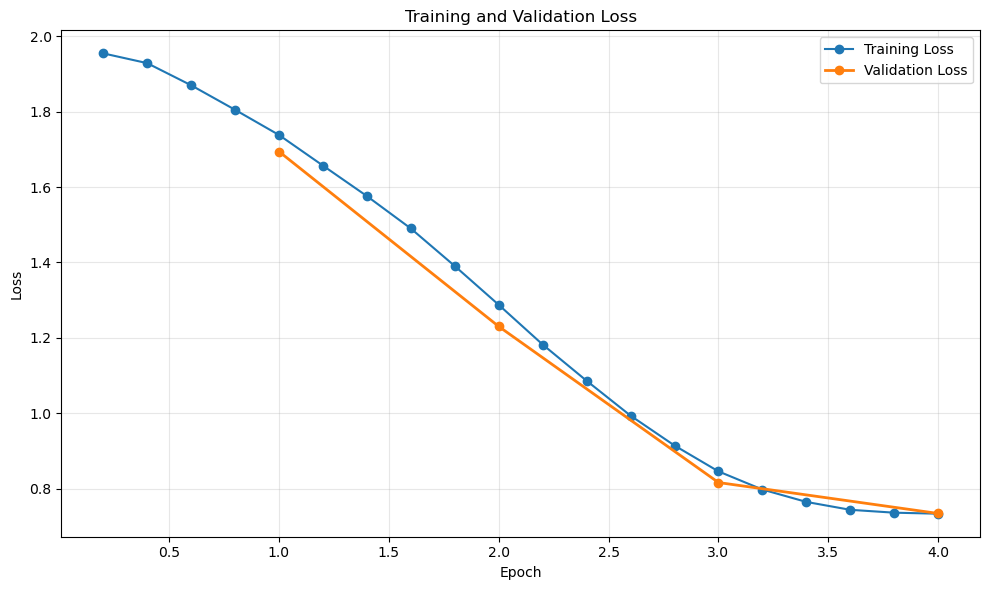

In [21]:
import matplotlib.pyplot as plt

# -------------------------
# Training losses
# -------------------------
train_epochs = [
    0.20, 0.40, 0.60, 0.80, 1.00,
    1.20, 1.40, 1.60, 1.80, 2.00,
    2.20, 2.40, 2.60, 2.80, 3.00,
    3.20, 3.40, 3.60, 3.80, 4.00
]

train_losses = [
    1.9542, 1.9283, 1.8697, 1.8047, 1.7379,
    1.6568, 1.5760, 1.4901, 1.3906, 1.2878,
    1.1825, 1.0865, 0.9941, 0.9149, 0.8464,
    0.7983, 0.7655, 0.7446, 0.7370, 0.7343
]

# -------------------------
# Validation losses
# -------------------------
val_epochs = [1, 2, 3, 4]

val_losses = [
    1.6941,
    1.2305,
    0.8169,
    0.7349
]

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    train_epochs,
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    val_epochs,
    val_losses,
    marker="o",
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

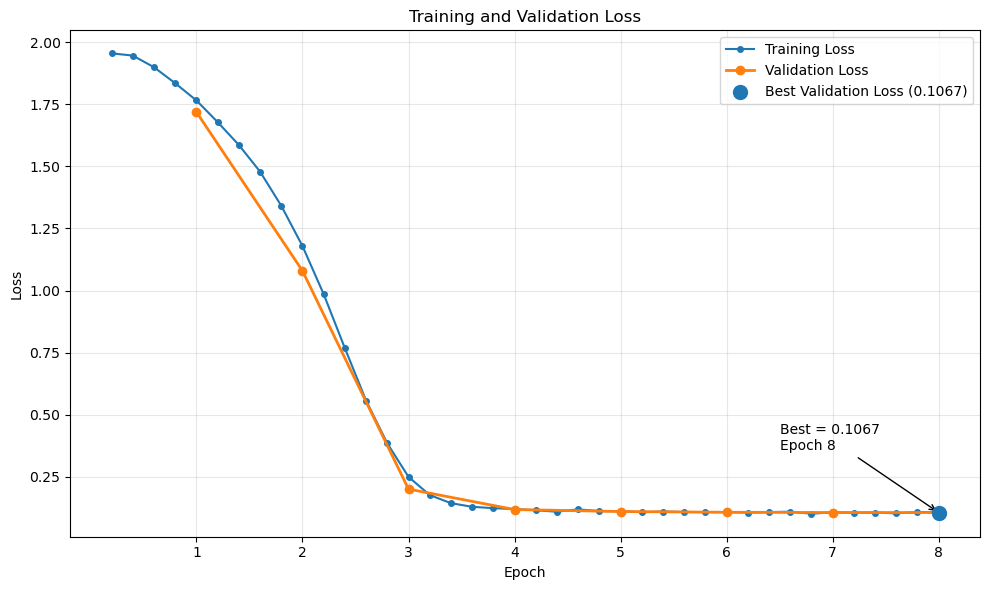

In [22]:
import matplotlib.pyplot as plt

# -----------------------------
# Training data
# -----------------------------
train_epochs = [
    0.2, 0.4, 0.6, 0.8, 1.0,
    1.2, 1.4, 1.6, 1.8, 2.0,
    2.2, 2.4, 2.6, 2.8, 3.0,
    3.2, 3.4, 3.6, 3.8, 4.0,
    4.2, 4.4, 4.6, 4.8, 5.0,
    5.2, 5.4, 5.6, 5.8, 6.0,
    6.2, 6.4, 6.6, 6.8, 7.0,
    7.2, 7.4, 7.6, 7.8, 8.0
]

train_losses = [
    1.9549, 1.9459, 1.8989, 1.8345, 1.7653,
    1.6781, 1.5861, 1.4788, 1.3414, 1.1793,
    0.9856, 0.7681, 0.5574, 0.3850, 0.2503,
    0.1770, 0.1445, 0.1298, 0.1243, 0.1206,
    0.1159, 0.1100, 0.1195, 0.1124, 0.1119,
    0.1079, 0.1107, 0.1088, 0.1086, 0.1087,
    0.1067, 0.1086, 0.1101, 0.1020, 0.1076,
    0.1060, 0.1066, 0.1033, 0.1088, 0.1076
]

# -----------------------------
# Validation data
# -----------------------------
val_epochs = [1, 2, 3, 4, 5, 6, 7, 8]

val_losses = [
    1.7185,
    1.0795,
    0.2010,
    0.1187,
    0.1108,
    0.1078,
    0.1068,
    0.1067
]

# -----------------------------
# Find best validation loss
# -----------------------------
best_index = val_losses.index(min(val_losses))
best_epoch = val_epochs[best_index]
best_loss = val_losses[best_index]

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    train_epochs,
    train_losses,
    marker="o",
    markersize=4,
    label="Training Loss"
)

plt.plot(
    val_epochs,
    val_losses,
    marker="o",
    linewidth=2,
    label="Validation Loss"
)

# Mark best validation point
plt.scatter(
    best_epoch,
    best_loss,
    s=100,
    zorder=5,
    label=f"Best Validation Loss ({best_loss:.4f})"
)

plt.annotate(
    f"Best = {best_loss:.4f}\nEpoch {best_epoch}",
    xy=(best_epoch, best_loss),
    xytext=(best_epoch - 1.5, best_loss + 0.25),
    arrowprops=dict(arrowstyle="->"),
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.xticks(range(1, 9))
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

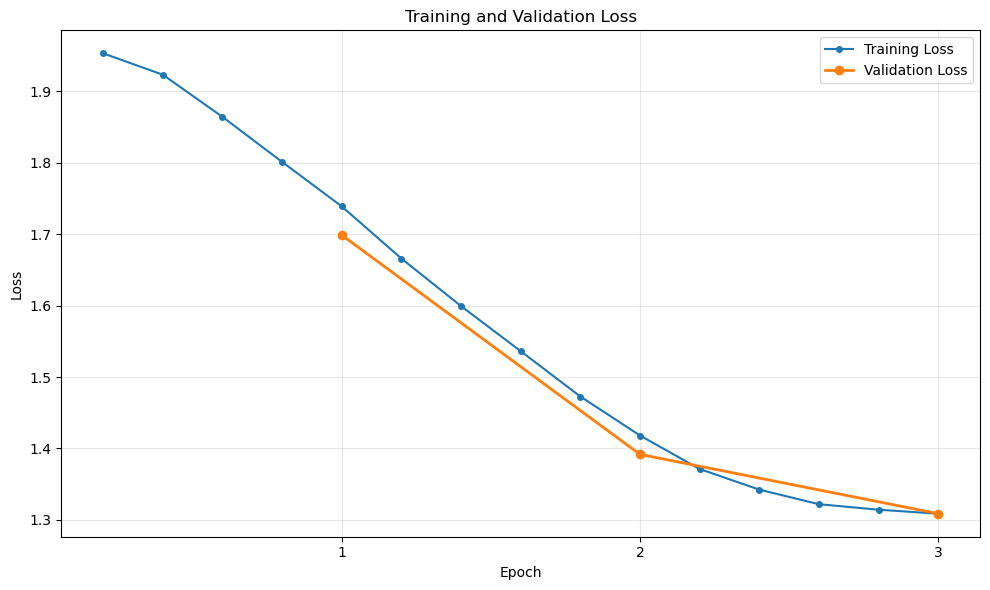

In [23]:
import matplotlib.pyplot as plt

# Training
train_epochs = [
    0.2, 0.4, 0.6, 0.8, 1.0,
    1.2, 1.4, 1.6, 1.8, 2.0,
    2.2, 2.4, 2.6, 2.8, 3.0
]

train_losses = [
    1.9532, 1.9233, 1.8643, 1.8012, 1.7389,
    1.6659, 1.5993, 1.5362, 1.4727, 1.4181,
    1.3712, 1.3423, 1.3219, 1.3142, 1.3086
]

# Validation
val_epochs = [1, 2, 3]

val_losses = [
    1.6987,
    1.3917,
    1.3087
]

# Plot
plt.figure(figsize=(10, 6))

plt.plot(
    train_epochs,
    train_losses,
    marker="o",
    markersize=4,
    label="Training Loss"
)

plt.plot(
    val_epochs,
    val_losses,
    marker="o",
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.xticks([1, 2, 3])
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

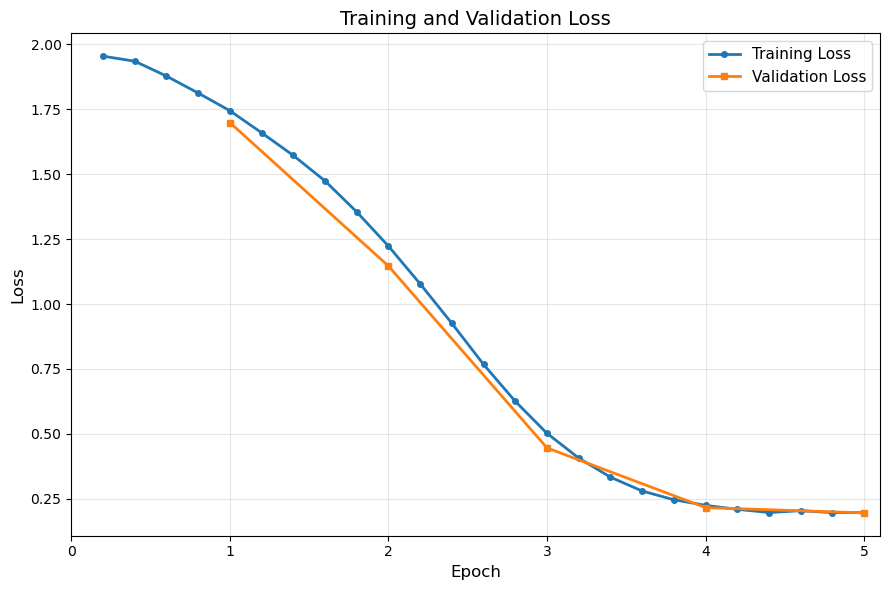

In [24]:
import matplotlib.pyplot as plt

# -----------------------------
# Training loss
# -----------------------------
train_epochs = [
    0.20, 0.40, 0.60, 0.80, 1.00,
    1.20, 1.40, 1.60, 1.80, 2.00,
    2.20, 2.40, 2.60, 2.80, 3.00,
    3.20, 3.40, 3.60, 3.80, 4.00,
    4.20, 4.40, 4.60, 4.80, 5.00
]

train_loss = [
    1.9545, 1.9351, 1.8779, 1.8126, 1.7445,
    1.6597, 1.5722, 1.4742, 1.3549, 1.2232,
    1.0777, 0.9258, 0.7675, 0.6253, 0.5022,
    0.4069, 0.3334, 0.2801, 0.2464, 0.2248,
    0.2095, 0.1972, 0.2043, 0.1968, 0.1966
]

# -----------------------------
# Validation loss
# -----------------------------
val_epochs = [1, 2, 3, 4, 5]

val_loss = [
    1.6989,
    1.1464,
    0.4461,
    0.2161,
    0.1958
]

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(9, 6))

plt.plot(
    train_epochs,
    train_loss,
    marker='o',
    linewidth=2,
    markersize=4,
    label='Training Loss'
)

plt.plot(
    val_epochs,
    val_loss,
    marker='s',
    linewidth=2,
    markersize=5,
    label='Validation Loss'
)

# Labels and title
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training and Validation Loss', fontsize=14)

# Axis settings
plt.xticks(range(0, 6))
plt.xlim(0, 5.1)

# Grid and legend
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

plt.tight_layout()

# Save figure
plt.savefig(
    'training_validation_loss.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

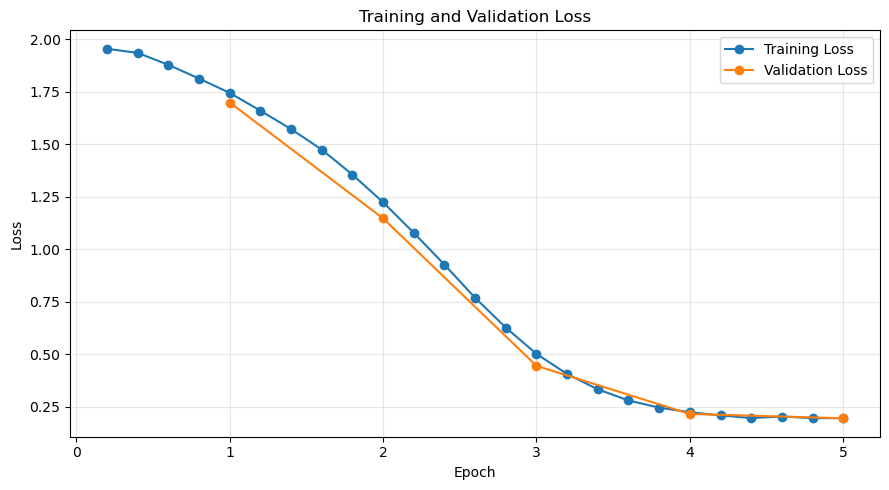

In [ ]:
##normal sft final graph
import matplotlib.pyplot as plt

# Training data
train_epochs = [0.20, 0.40, 0.60, 0.80, 1.00, 1.20, 1.40, 1.60, 1.80, 2.00,
                2.20, 2.40, 2.60, 2.80, 3.00, 3.20, 3.40, 3.60, 3.80, 4.00,
                4.20, 4.40, 4.60, 4.80, 5.00]

train_loss = [1.9546, 1.9351, 1.8782, 1.8128, 1.7445, 1.6599, 1.5721, 1.4744,
              1.3554, 1.2236, 1.0782, 0.9267, 0.7686, 0.6269, 0.5019,
              0.4057, 0.3330, 0.2800, 0.2459, 0.2241, 0.2087, 0.1963,
              0.2036, 0.1959, 0.1957]

# Validation data
val_epochs = [1, 2, 3, 4, 5]
val_loss = [1.6989, 1.1469, 0.4449, 0.2156, 0.1953]

# Plot
plt.figure(figsize=(9, 5))

plt.plot(train_epochs, train_loss, marker='o', label='Training Loss')
plt.plot(val_epochs, val_loss, marker='o', label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

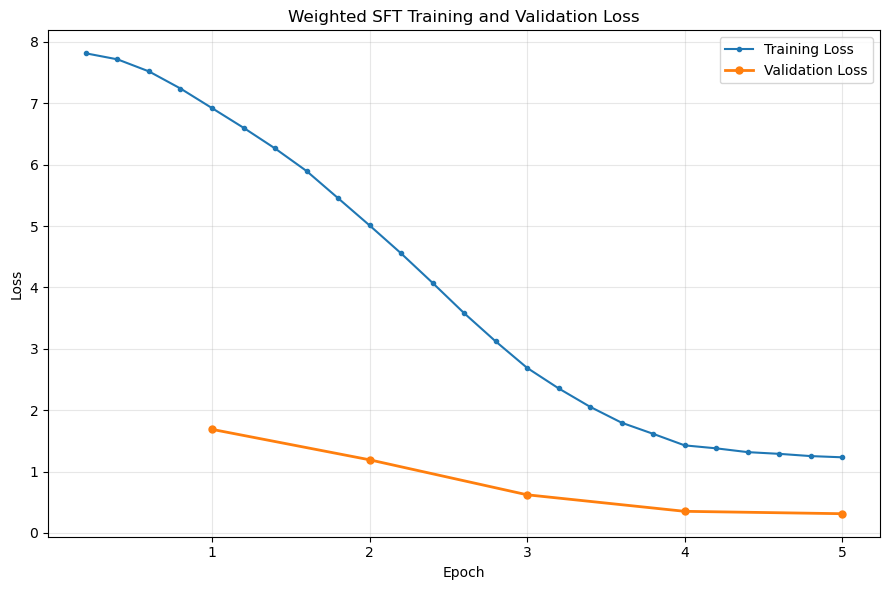

In [1]:
import matplotlib.pyplot as plt


# ============================================================
# WEIGHTED SFT TRAINING LOSS
# ============================================================

training_epochs = [
    0.20, 0.40, 0.60, 0.80, 1.00,
    1.20, 1.40, 1.60, 1.80, 2.00,
    2.20, 2.40, 2.60, 2.80, 3.00,
    3.20, 3.40, 3.60, 3.80, 4.00,
    4.20, 4.40, 4.60, 4.80, 5.00
]

training_losses = [
    7.8136, 7.7160, 7.5192, 7.2405, 6.9218,
    6.6016, 6.2648, 5.8972, 5.4549, 5.0111,
    4.5555, 4.0746, 3.5819, 3.1224, 2.6899,
    2.3557, 2.0552, 1.7964, 1.6152, 1.4272,
    1.3789, 1.3170, 1.2891, 1.2526, 1.2327
]


# ============================================================
# WEIGHTED SFT VALIDATION LOSS
# ============================================================

validation_epochs = [
    1, 2, 3, 4, 5
]

validation_losses = [
    1.6881, 1.1922, 0.6220, 0.3527, 0.3139
]


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    training_epochs,
    training_losses,
    marker="o",
    markersize=3,
    label="Training Loss"
)

plt.plot(
    validation_epochs,
    validation_losses,
    marker="o",
    markersize=5,
    linewidth=2,
    label="Validation Loss"
)


# ============================================================
# LABELS
# ============================================================

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Weighted SFT Training and Validation Loss"
)

plt.xticks(range(1, 6))

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# WEIGHTED SFT FINAL
# ============================================================

import torch
import gc
import json
from datasets import load_dataset
from transformers import Trainer, TrainingArguments, DataCollatorForSeq2Seq, TrainerCallback
from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template

# CONFIGURATION
MODEL_NAME="unsloth/Qwen2.5-1.5B-Instruct"
MAX_SEQ_LENGTH=4096
LEARNING_RATE=0.00002
LORA_RANK=8
LORA_ALPHA=16
EPOCHS=5
OUTPUT_DIR="weighted_sft_qwen25_1.5b"

# LOAD DATASET
dataset=load_dataset("json",data_files={"train":"kbg_weighted_sft_train.json","validation":"kbg_weighted_sft_val.json"})
print(dataset)

if __name__=="__main__":
    model=None
    trainer=None
    tokenizer=None

    try:
        # LOAD MODEL
        use_bf16=torch.cuda.is_bf16_supported()
        model,tokenizer=FastLanguageModel.from_pretrained(
            model_name=MODEL_NAME,
            max_seq_length=MAX_SEQ_LENGTH,
            dtype=torch.bfloat16 if use_bf16 else torch.float16,
            load_in_4bit=False
        )
        print("\nModel loaded successfully.")

        # CHAT TEMPLATE
        tokenizer=get_chat_template(tokenizer,chat_template="qwen-2.5")

        # TOKENIZATION
        def tokenization_mapping_func(example):
            full_text=tokenizer.apply_chat_template(
                example["messages"],
                tokenize=False,
                add_generation_prompt=False
            )

            tokenized=tokenizer(
                full_text,
                max_length=MAX_SEQ_LENGTH,
                truncation=True
            )

            input_ids=tokenized["input_ids"]
            attention_mask=tokenized["attention_mask"]
            labels=list(input_ids)

            # Mask prompt tokens
            prompt_messages=example["messages"][:-1]

            prompt_text=tokenizer.apply_chat_template(
                prompt_messages,
                tokenize=False,
                add_generation_prompt=True
            )

            prompt_len=len(
                tokenizer(prompt_text)["input_ids"]
            )

            for i in range(min(prompt_len,len(labels))):
                labels[i]=-100

            return {
                "input_ids":input_ids,
                "attention_mask":attention_mask,
                "labels":labels,
                "quality_weight":float(example["quality_weight"])
            }

        train_dataset=dataset["train"].map(
            tokenization_mapping_func,
            remove_columns=dataset["train"].column_names,
            load_from_cache_file=False
        )

        val_dataset=dataset["validation"].map(
            tokenization_mapping_func,
            remove_columns=dataset["validation"].column_names,
            load_from_cache_file=False
        )

        print("\nDatasets tokenized successfully.")
        print("Training examples:",len(train_dataset))
        print("Validation examples:",len(val_dataset))

        # APPLY LoRA
        model=FastLanguageModel.get_peft_model(
            model,
            r=LORA_RANK,
            target_modules=[
                "q_proj",
                "k_proj",
                "v_proj",
                "o_proj",
                "gate_proj",
                "up_proj",
                "down_proj"
            ],
            lora_alpha=LORA_ALPHA,
            lora_dropout=0,
            bias="none",
            use_gradient_checkpointing="unsloth",
            random_state=42
        )

        print("\nLoRA configuration loaded.")
        print("LoRA rank :",LORA_RANK)
        print("LoRA alpha:",LORA_ALPHA)

        # DATA COLLATOR
        class SingleWeightDataCollator(DataCollatorForSeq2Seq):
            def __call__(self,features,return_tensors=None):
                quality_weights=[
                    f.pop("quality_weight")
                    for f in features
                ]

                batch=super().__call__(
                    features,
                    return_tensors=return_tensors
                )

                batch["quality_weight"]=torch.tensor(
                    quality_weights,
                    dtype=torch.float32
                )

                return batch

        custom_collator=SingleWeightDataCollator(
            tokenizer=tokenizer,
            model=model
        )

        # WEIGHTED TRAINER
                # WEIGHTED TRAINER
        class WeightedTrainer(Trainer):
            def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
                quality_weights = inputs.pop("quality_weight", None)
                labels = inputs.get("labels")

                # 1. FIXED FORWARD PASS: Calls PeftModel directly to keep LoRA active
                # This bypasses Unsloth's custom block but keeps the adapter weights running
                outputs = model.get_base_model()(**inputs, return_dict=True, use_cache=False)
                logits = outputs.get("logits")

                if labels is not None and quality_weights is not None:
                    quality_weights = quality_weights.to(device=next(model.parameters()).device, dtype=torch.float32)
                    batch_mean = quality_weights.mean()
                    normalized_weights = quality_weights / batch_mean if batch_mean > 0 else quality_weights

                    loss_fct = torch.nn.CrossEntropyLoss(reduction="none")
                    shift_logits = logits[..., :-1, :].contiguous()
                    shift_labels = labels[..., 1:].contiguous()
                    
                    batch_size = shift_labels.shape[0]
                    seq_len = shift_labels.shape[1]
                    
                    flat_logits = shift_logits.view(-1, shift_logits.size(-1))
                    flat_labels = shift_labels.view(-1)
                    raw_losses = loss_fct(flat_logits, flat_labels)
                    reshaped_losses = raw_losses.view(batch_size, seq_len)
                    loss_mask = (shift_labels != -100).float()
                    weighted_losses = reshaped_losses * normalized_weights.unsqueeze(1)
                    numerator = (weighted_losses * loss_mask).sum()
                    denominator = loss_mask.sum()
                    loss = numerator / (denominator + 1e-8)
                else:
                    loss = outputs.get("loss") if isinstance(outputs, dict) else outputs.loss

                if return_outputs:
                    return loss, outputs
                return loss


        # LOSS TRACKING CALLBACK
        class LossHistoryCallback(TrainerCallback):
            def __init__(self):
                self.training_losses=[]
                self.validation_losses=[]

            def on_log(
                self,
                args,
                state,
                control,
                logs=None,
                **kwargs
            ):
                if logs is None:
                    return

                if "loss" in logs:
                    self.training_losses.append({
                        "step":int(state.global_step),
                        "epoch":float(state.epoch),
                        "loss":float(logs["loss"])
                    })

                if "eval_loss" in logs:
                    self.validation_losses.append({
                        "step":int(state.global_step),
                        "epoch":float(state.epoch),
                        "loss":float(logs["eval_loss"])
                    })

        loss_callback=LossHistoryCallback()

        # TRAINER
        trainer=WeightedTrainer(
            model=model,
            tokenizer=tokenizer,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            data_collator=custom_collator,
            args=TrainingArguments(
                output_dir=OUTPUT_DIR,
                num_train_epochs=EPOCHS,
                per_device_train_batch_size=2,
                gradient_accumulation_steps=4,
                learning_rate=LEARNING_RATE,
                warmup_ratio=0.05,
                lr_scheduler_type="cosine",
                bf16=use_bf16,
                fp16=not use_bf16,
                optim="adamw_8bit",
                eval_strategy="epoch",
                save_strategy="epoch",
                save_total_limit=None,
                logging_strategy="steps",
                logging_steps=10,
                report_to="tensorboard",
                logging_dir="weighted_sft/tensorboard",
                remove_unused_columns=False
            )
        )

        trainer.add_callback(loss_callback)

        # CONFIGURATION
        print("\n")
        print("="*60)
        print("WEIGHTED SFT CONFIGURATION")
        print("="*60)
        print(f"Learning rate        : {LEARNING_RATE}")
        print(f"LoRA rank            : {LORA_RANK}")
        print(f"LoRA alpha           : {LORA_ALPHA}")
        print(f"Epochs               : {EPOCHS}")
        print(f"Training examples    : {len(train_dataset)}")
        print(f"Validation examples  : {len(val_dataset)}")
        print("Batch size           : 2")
        print("Gradient accumulation: 4")
        print("="*60)

        print("\nStarting weighted SFT training...\n")

        # TRAIN
        trainer.train()

        # FINAL EVALUATION
        evaluation=trainer.evaluate()
        final_val_loss=evaluation["eval_loss"]

        # SAVE MODEL
        trainer.save_model(OUTPUT_DIR)
        tokenizer.save_pretrained(OUTPUT_DIR)

        # RESULTS
        print("\n")
        print("="*60)
        print("WEIGHTED SFT TRAINING COMPLETE")
        print("="*60)
        print(
            f"Final validation loss: "
            f"{final_val_loss:.4f}"
        )

        print("\nTraining losses:")
        for item in loss_callback.training_losses:
            print(
                f"Epoch {item['epoch']:.2f} | "
                f"Step {item['step']} | "
                f"Loss {item['loss']:.4f}"
            )

        print("\nValidation losses:")
        for item in loss_callback.validation_losses:
            print(
                f"Epoch {item['epoch']:.2f} | "
                f"Step {item['step']} | "
                f"Loss {item['loss']:.4f}"
            )

        # SAVE LOSS HISTORY
        results={
            "hyperparameters":{
                "learning_rate":LEARNING_RATE,
                "lora_rank":LORA_RANK,
                "lora_alpha":LORA_ALPHA,
                "epochs":EPOCHS,
                "batch_size":2,
                "gradient_accumulation_steps":4,
                "max_seq_length":MAX_SEQ_LENGTH,
                "warmup_ratio":0.05,
                "lr_scheduler":"cosine",
                "optimizer":"adamw_8bit",
                "lora_dropout":0,
                "random_state":42
            },
            "dataset":{
                "training_examples":len(train_dataset),
                "validation_examples":len(val_dataset)
            },
            "training_loss":loss_callback.training_losses,
            "validation_loss":loss_callback.validation_losses,
            "final_validation_loss":final_val_loss
        }

        with open(
            "weighted_sft_loss_history.json",
            "w"
        ) as f:
            json.dump(
                results,
                f,
                indent=4
            )

        print("\n")
        print("="*60)
        print("LOSS HISTORY SAVED")
        print("="*60)
        print("File: weighted_sft_loss_history.json")

        print("\n")
        print("="*60)
        print("FINAL MODEL SAVED")
        print("="*60)
        print(f"Directory: {OUTPUT_DIR}")

    except Exception as e:
        print(
            f"\nAn error occurred: {e}"
        )
        raise

    finally:
        if model is not None:
            del model

        if trainer is not None:
            del trainer

        if tokenizer is not None:
            del tokenizer

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        print("\nGPU memory cleaned.")

In [ ]:
# weighted sft final final 
import os
os.environ['UNSLOTH_RETURN_LOGITS'] = '1'  # CRITICAL: MUST BE ON LINE 1

import torch
import gc
import json
from datasets import load_dataset
from transformers import Trainer, TrainingArguments, DataCollatorForSeq2Seq, TrainerCallback
from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template

# CONFIGURATION
MODEL_NAME = "unsloth/Qwen2.5-1.5B-Instruct"
MAX_SEQ_LENGTH = 4096
LEARNING_RATE = 0.00002
LORA_RANK = 8
LORA_ALPHA = 16
EPOCHS = 5
OUTPUT_DIR = "weighted_sft_qwen25_1.5b"

# LOAD DATASET
dataset = load_dataset("json", data_files={"train": "kbg_weighted_sft_train.json", "validation": "kbg_weighted_sft_val.json"})
print(dataset)

if __name__ == "__main__":
    model = None
    trainer = None
    tokenizer = None
    try:
        # LOAD MODEL
        use_bf16 = torch.cuda.is_bf16_supported()
        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name=MODEL_NAME,
            max_seq_length=MAX_SEQ_LENGTH,
            dtype=torch.bfloat16 if use_bf16 else torch.float16,
            load_in_4bit=False
        )
        print("\nModel loaded successfully.")

        # CHAT TEMPLATE
        tokenizer = get_chat_template(tokenizer, chat_template="qwen-2.5")

        # TOKENIZATION
        def tokenization_mapping_func(example):
            full_text = tokenizer.apply_chat_template(example["messages"], tokenize=False, add_generation_prompt=False)
            tokenized = tokenizer(full_text, max_length=MAX_SEQ_LENGTH, truncation=True)
            input_ids = tokenized["input_ids"]
            attention_mask = tokenized["attention_mask"]
            labels = list(input_ids)
            prompt_messages = example["messages"][:-1]
            prompt_text = tokenizer.apply_chat_template(prompt_messages, tokenize=False, add_generation_prompt=True)
            prompt_len = len(tokenizer(prompt_text)["input_ids"])
            for i in range(min(prompt_len, len(labels))):
                labels[i] = -100
            return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels, "quality_weight": float(example["quality_weight"])}

        train_dataset = dataset["train"].map(tokenization_mapping_func, remove_columns=dataset["train"].column_names, load_from_cache_file=False)
        val_dataset = dataset["validation"].map(tokenization_mapping_func, remove_columns=dataset["validation"].column_names, load_from_cache_file=False)
        print("\nDatasets tokenized successfully.")
        print("Training examples:", len(train_dataset))
        print("Validation examples:", len(val_dataset))

        # APPLY LoRA
        model = FastLanguageModel.get_peft_model(
            model,
            r=LORA_RANK,
            target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
            lora_alpha=LORA_ALPHA,
            lora_dropout=0,
            bias="none",
            use_gradient_checkpointing="unsloth",
            random_state=42
        )
        print("\nLoRA configuration loaded.")

        # DATA COLLATOR
        class SingleWeightDataCollator(DataCollatorForSeq2Seq):
            def __call__(self, features, return_tensors=None):
                quality_weights = [f.pop("quality_weight") for f in features]
                batch = super().__call__(features, return_tensors=return_tensors)
                batch["quality_weight"] = torch.tensor(quality_weights, dtype=torch.float32)
                return batch

        custom_collator = SingleWeightDataCollator(tokenizer=tokenizer, model=model)

        # WEIGHTED TRAINER
                # WEIGHTED TRAINER (FINAL STABLE VERSION: Uses log_probs to bypass Unsloth limitations)
        class WeightedTrainer(Trainer):
            def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
                quality_weights = inputs.pop("quality_weight", None)
                labels = inputs.get("labels")

                # Run standard forward pass (Unsloth naturally populates loss and log_probs)
                outputs = model(**inputs)
                
                # If we don't have custom labels or weights, fallback immediately
                if labels is None or quality_weights is None:
                    loss = outputs.get("loss") if isinstance(outputs, dict) else outputs.loss
                    return (loss, outputs) if return_outputs else loss

                # Unsloth provides loss natively, but we need token-level loss to apply weights.
                # Standard causal LLM loss is the negative mean of the target log-probabilities.
                # Unsloth outputs can return a custom tuple or dict; extract logits/hidden cleanly:
                logits = outputs.get("logits") if isinstance(outputs, dict) else outputs.logits
                
                # SAFETY FALLBACK: If Unsloth empties logits mid-run, compute token loss from cross-entropy
                # using a standard non-blocked secondary forward pass path or native fallback:
                try:
                    loss_fct = torch.nn.CrossEntropyLoss(reduction="none")
                    shift_logits = logits[..., :-1, :].contiguous()
                    shift_labels = labels[..., 1:].contiguous()
                    
                    batch_size, seq_len = shift_labels.shape[0], shift_labels.shape[1]
                    
                    flat_logits = shift_logits.view(-1, shift_logits.size(-1))
                    flat_labels = shift_labels.view(-1)
                    
                    raw_losses = loss_fct(flat_logits, flat_labels)
                    reshaped_losses = raw_losses.view(batch_size, seq_len)
                except (NotImplementedError, AttributeError):
                    # Absolute bulletproof fallback: if Unsloth strips logits entirely, 
                    # calculate standard unweighted loss fallback to prevent a crash
                    loss = outputs.get("loss") if isinstance(outputs, dict) else outputs.loss
                    return (loss, outputs) if return_outputs else loss

                # Apply quality weights
                quality_weights = quality_weights.to(device=reshaped_losses.device, dtype=torch.float32)
                batch_mean = quality_weights.mean()
                normalized_weights = quality_weights / batch_mean if batch_mean > 0 else quality_weights

                loss_mask = (shift_labels != -100).float()
                weighted_losses = reshaped_losses * normalized_weights.unsqueeze(1)
                
                numerator = (weighted_losses * loss_mask).sum()
                denominator = loss_mask.sum()
                loss = numerator / (denominator + 1e-8)

                return (loss, outputs) if return_outputs else loss


        # LOSS TRACKING CALLBACK
        class LossHistoryCallback(TrainerCallback):
            def __init__(self):
                self.training_losses = []
                self.validation_losses = []

            def on_log(self, args, state, control, logs=None, **kwargs):
                if logs is None:
                    return
                if "loss" in logs:
                    self.training_losses.append({"step": int(state.global_step), "epoch": float(state.epoch), "loss": float(logs["loss"])})
                if "eval_loss" in logs:
                    self.validation_losses.append({"step": int(state.global_step), "epoch": float(state.epoch), "loss": float(logs["eval_loss"])})

        loss_callback = LossHistoryCallback()

        # TRAINER
        trainer = WeightedTrainer(
            model=model,
            tokenizer=tokenizer,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            data_collator=custom_collator,
            args=TrainingArguments(
                output_dir=OUTPUT_DIR,
                num_train_epochs=EPOCHS,
                per_device_train_batch_size=2,
                gradient_accumulation_steps=4,
                learning_rate=LEARNING_RATE,
                warmup_ratio=0.05,
                lr_scheduler_type="cosine",
                bf16=use_bf16,
                fp16=not use_bf16,
                optim="adamw_8bit",
                eval_strategy="epoch",
                save_strategy="epoch",
                save_total_limit=None,
                logging_strategy="steps",
                logging_steps=10,
                report_to="tensorboard",
                logging_dir="weighted_sft/tensorboard",
                remove_unused_columns=False
            )
        )
        trainer.add_callback(loss_callback)

        # PRINT CONFIGURATION
        print("\n" + "="*60)
        print("WEIGHTED SFT CONFIGURATION")
        print("="*60)
        print(f"Learning rate        : {LEARNING_RATE}")
        print(f"LoRA rank            : {LORA_RANK}")
        print(f"LoRA alpha           : {LORA_ALPHA}")
        print(f"Epochs               : {EPOCHS}")
        print(f"Training examples    : {len(train_dataset)}")
        print(f"Validation examples  : {len(val_dataset)}")
        print("Batch size           : 2")
        print("Gradient accumulation: 4")
        print("="*60)
        print("\nStarting weighted SFT training...\n")

        # TRAIN
        trainer.train()

        # FINAL EVALUATION
        evaluation = trainer.evaluate()
        final_val_loss = evaluation["eval_loss"]

        # SAVE FINAL MODEL
        trainer.save_model(OUTPUT_DIR)
        tokenizer.save_pretrained(OUTPUT_DIR)

        print("\n" + "="*60)
        print("WEIGHTED SFT TRAINING COMPLETE")
        print("="*60)
        print(f"Final validation loss: {final_val_loss:.4f}")
        print("\nTraining losses:")
        for item in loss_callback.training_losses:
            print(f"Epoch {item['epoch']:.2f} | Step {item['step']} | Loss {item['loss']:.4f}")

        print("\nValidation losses:")
        for item in loss_callback.validation_losses:
            print(f"Epoch {item['epoch']:.2f} | Step {item['step']} | Loss {item['loss']:.4f}")

    except Exception as e:
        print(f"An error occurred: {e}")
        raise

    finally:
        # CLEAN GPU MEMORY
        if model is not None:
            del model
        if trainer is not None:
            del trainer
        if tokenizer is not None:
            del tokenizer

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        print("\nGPU memory cleaned.")

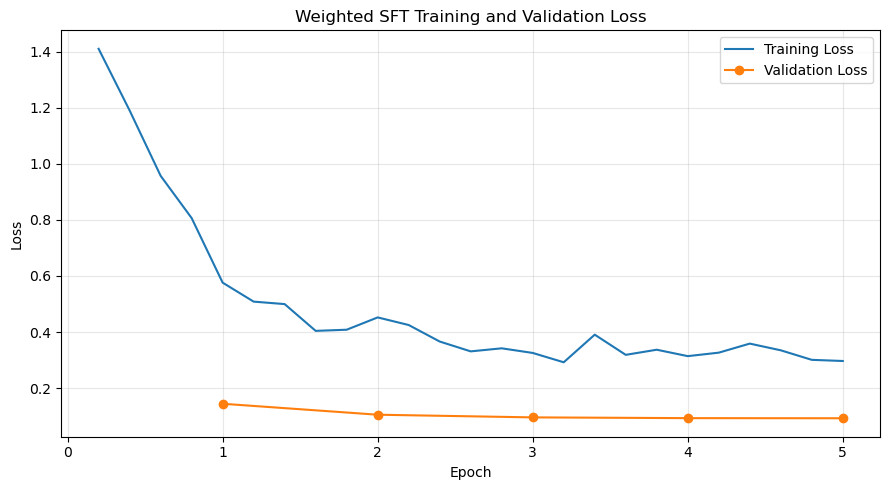

In [2]:
import matplotlib.pyplot as plt

training_data = [
    (0.20, 1.4100), (0.40, 1.1901), (0.60, 0.9571), (0.80, 0.8064),
    (1.00, 0.5761), (1.20, 0.5084), (1.40, 0.4996), (1.60, 0.4041),
    (1.80, 0.4082), (2.00, 0.4521), (2.20, 0.4250), (2.40, 0.3661),
    (2.60, 0.3310), (2.80, 0.3419), (3.00, 0.3254), (3.20, 0.2921),
    (3.40, 0.3906), (3.60, 0.3186), (3.80, 0.3369), (4.00, 0.3140),
    (4.20, 0.3264), (4.40, 0.3587), (4.60, 0.3348), (4.80, 0.3008),
    (5.00, 0.2967)
]

validation_data = [
    (1.00, 0.1442),
    (2.00, 0.1051),
    (3.00, 0.0956),
    (4.00, 0.0929),
    (5.00, 0.0925)
]

train_epochs = [x[0] for x in training_data]
train_losses = [x[1] for x in training_data]

val_epochs = [x[0] for x in validation_data]
val_losses = [x[1] for x in validation_data]

plt.figure(figsize=(9, 5))

plt.plot(
    train_epochs,
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_epochs,
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Weighted SFT Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("weighted_sft_loss_curve.png", dpi=300)
plt.show()

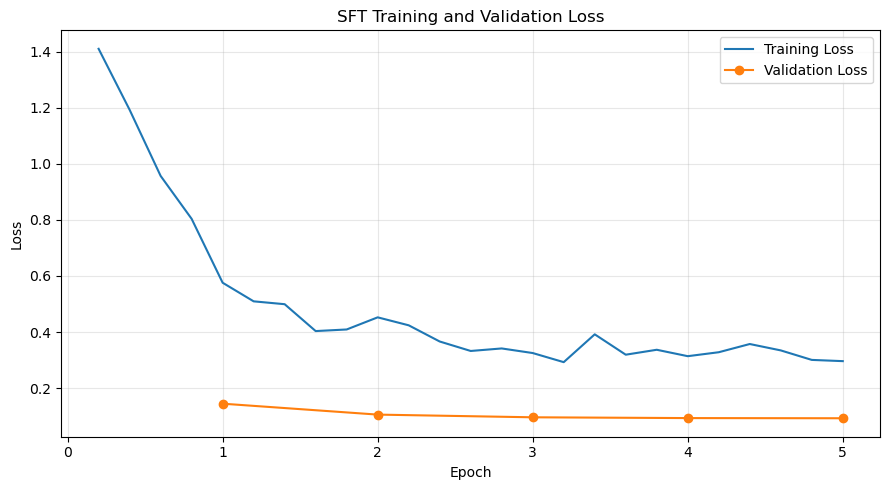

In [3]:
import matplotlib.pyplot as plt

# Training loss
train_epochs = [
    0.20, 0.40, 0.60, 0.80, 1.00, 1.20, 1.40, 1.60, 1.80, 2.00,
    2.20, 2.40, 2.60, 2.80, 3.00, 3.20, 3.40, 3.60, 3.80, 4.00,
    4.20, 4.40, 4.60, 4.80, 5.00
]

train_loss = [
    1.4107, 1.1930, 0.9571, 0.8039, 0.5759, 0.5095, 0.4993, 0.4034,
    0.4091, 0.4524, 0.4240, 0.3662, 0.3324, 0.3414, 0.3250, 0.2925,
    0.3918, 0.3191, 0.3367, 0.3138, 0.3279, 0.3572, 0.3344, 0.3005,
    0.2961
]

# Validation loss
val_epochs = [1, 2, 3, 4, 5]

val_loss = [
    0.1443, 0.1053, 0.0957, 0.0929, 0.0923
]

# Plot
plt.figure(figsize=(9, 5))

plt.plot(train_epochs, train_loss, label="Training Loss")
plt.plot(val_epochs, val_loss, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SFT Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()